# Notebook 01 — Exploratory Data Analysis
## FORCE 2020 Well Log Lithofacies Dataset

**Goal:** Understand the dataset, visualise well log curves, analyse lithofacies
distributions, and identify which curves are reliably available across all 118 wells.

**Key questions:**
1. Which log curves are available across most wells?
2. How are the 12 lithofacies classes distributed?
3. What do the log curves look like per lithofacies?
4. What null value patterns exist and how should we handle them?


In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import lasio
from pathlib import Path
from tqdm import tqdm

from config import LAS_DIR, LITH_MAP, LITH_COLORS, STANDARD_CURVES, CORE_CURVES
from config import TARGET_COL, DEPTH_COL, FIGS

FIGS.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "#f8f9fa"

print(f"LAS directory : {LAS_DIR}")
las_files = sorted(LAS_DIR.glob("*.las"))
print(f"LAS files     : {len(las_files)}")
print(f"Sample wells  : {[f.stem for f in las_files[:5]]}")


LAS directory : C:\Users\takum\OneDrive\Documents\wellvision\data\raw\force2020\Force_2020_all_wells_train_test_blind_hidden_final
LAS files     : 118
Sample wells  : ['15_9-13', '15_9-14', '15_9-15', '15_9-17', '15_9-23']


## 1. Load all 118 wells into a combined DataFrame

In [2]:
def load_las(path):
    try:
        las = lasio.read(path, ignore_header_errors=True)
        df  = las.df().reset_index()
        df.columns = [c.upper() for c in df.columns]
        if "DEPT" in df.columns and "DEPTH_MD" not in df.columns:
            df = df.rename(columns={"DEPT": "DEPTH_MD"})
        df["WELL"] = path.stem
        df = df.replace(-999.25, np.nan).replace(-9999.0, np.nan)
        if TARGET_COL in df.columns:
            df["LITHOFACIES"] = df[TARGET_COL].map(LITH_MAP)
        return df
    except Exception as e:
        print(f"  Warning: {path.name} — {e}")
        return None

print("Loading all wells...")
dfs = []
for f in tqdm(las_files, ncols=80):
    df = load_las(f)
    if df is not None:
        dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
print(f"Combined shape : {combined.shape}")
print(f"Wells loaded   : {combined['WELL'].nunique()}")
print(f"Total samples  : {len(combined):,}")


Loading all wells...


100%|█████████████████████████████████████████| 118/118 [00:46<00:00,  2.56it/s]


Combined shape : (2337639, 29)
Wells loaded   : 118
Total samples  : 2,337,639


In [3]:
print("Depth range (m):")
print(f"  Min : {combined[DEPTH_COL].min():.1f}")
print(f"  Max : {combined[DEPTH_COL].max():.1f}")
well_counts = combined.groupby("WELL").size()
print(f"Samples per well:")
print(well_counts.describe().round(0))


Depth range (m):
  Min : 98.7
  Max : 5477.7
Samples per well:
count      118.0
mean     19810.0
std       5608.0
min       6059.0
25%      16236.0
50%      19612.0
75%      23859.0
max      35896.0
dtype: float64


## 2. Curve availability across all wells

In [4]:
skip_cols = {"WELL","DEPTH_MD","LITHOFACIES",TARGET_COL,
             "FORCE_2020_LITHOFACIES_CONFIDENCE","X_LOC","Y_LOC","Z_LOC"}
all_curves = [c for c in combined.columns if c not in skip_cols]

curve_availability = {}
for curve in all_curves:
    wells_with = combined.groupby("WELL")[curve].apply(
        lambda x: x.notna().sum() > 10).sum()
    cov_pct = combined[curve].notna().mean() * 100
    curve_availability[curve] = {"wells": int(wells_with), "coverage_pct": round(cov_pct,1)}

avail_df = pd.DataFrame(curve_availability).T.sort_values("wells", ascending=False)
print(avail_df.to_string())


           wells  coverage_pct
DEPT       118.0         100.0
RDEP       118.0          94.9
DTC        118.0          76.7
GR         118.0          98.3
NPHI       118.0          44.2
RHOB       118.0          59.7
RMED       117.0          89.5
CALI       117.0          62.5
DRHO       114.0          56.7
PEF         88.0          39.5
BS          83.0          62.3
RSHA        82.0          37.2
SP          76.0          52.6
ROP         67.0          52.2
DTS         46.0          16.6
RXO         43.0          16.5
ROPA        38.0          31.6
RMIC        34.0          10.2
MUDWEIGHT   29.0          18.8
DCAL        28.0          16.4
SGR         14.0           3.1


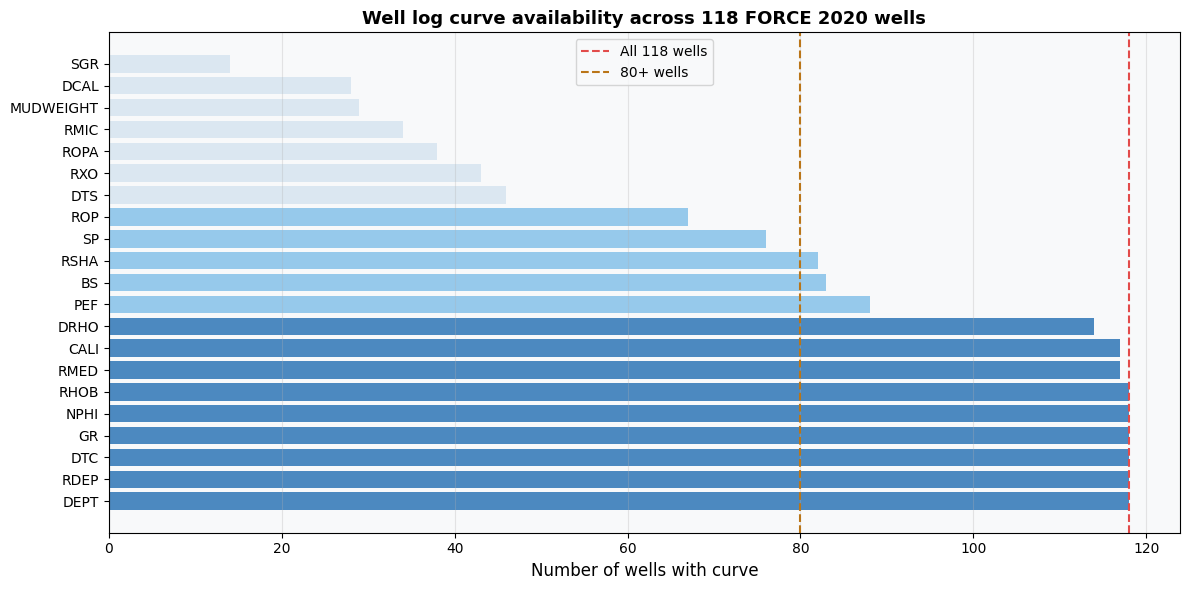

Saved fig01_curve_availability.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#2E75B6" if w >= 100 else "#85C1E9" if w >= 50 else "#D6E4F0"
          for w in avail_df["wells"]]
ax.barh(avail_df.index, avail_df["wells"], color=colors, alpha=0.85)
ax.axvline(x=118, color="#E24B4A", linestyle="--", lw=1.5, label="All 118 wells")
ax.axvline(x=80,  color="#BA7517", linestyle="--", lw=1.5, label="80+ wells")
ax.set_xlabel("Number of wells with curve", fontsize=12)
ax.set_title("Well log curve availability across 118 FORCE 2020 wells", fontweight="bold", fontsize=13)
ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / "fig01_curve_availability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig01_curve_availability.png")


## 3. Lithofacies class distribution

In [6]:
labelled = combined[combined["LITHOFACIES"].notna()].copy()
print(f"Labelled samples : {len(labelled):,}")
print(f"Labelled wells   : {labelled['WELL'].nunique()}")

lith_counts = labelled["LITHOFACIES"].value_counts()
for lith, count in lith_counts.items():
    pct = count / len(labelled) * 100
    print(f"  {lith:<25} {count:>8,}  ({pct:5.1f}%)")


Labelled samples : 1,431,242
Labelled wells   : 118
  Shale                      877,043  ( 61.3%)
  Sandstone                  207,704  ( 14.5%)
  Sandstone/Shale            180,820  ( 12.6%)
  Limestone                   69,498  (  4.9%)
  Marl                        41,038  (  2.9%)
  Tuff                        17,431  (  1.2%)
  Halite                      14,712  (  1.0%)
  Chalk                       14,043  (  1.0%)
  Basement                     4,754  (  0.3%)
  Dolomite                     2,391  (  0.2%)
  Anhydrite                    1,808  (  0.1%)


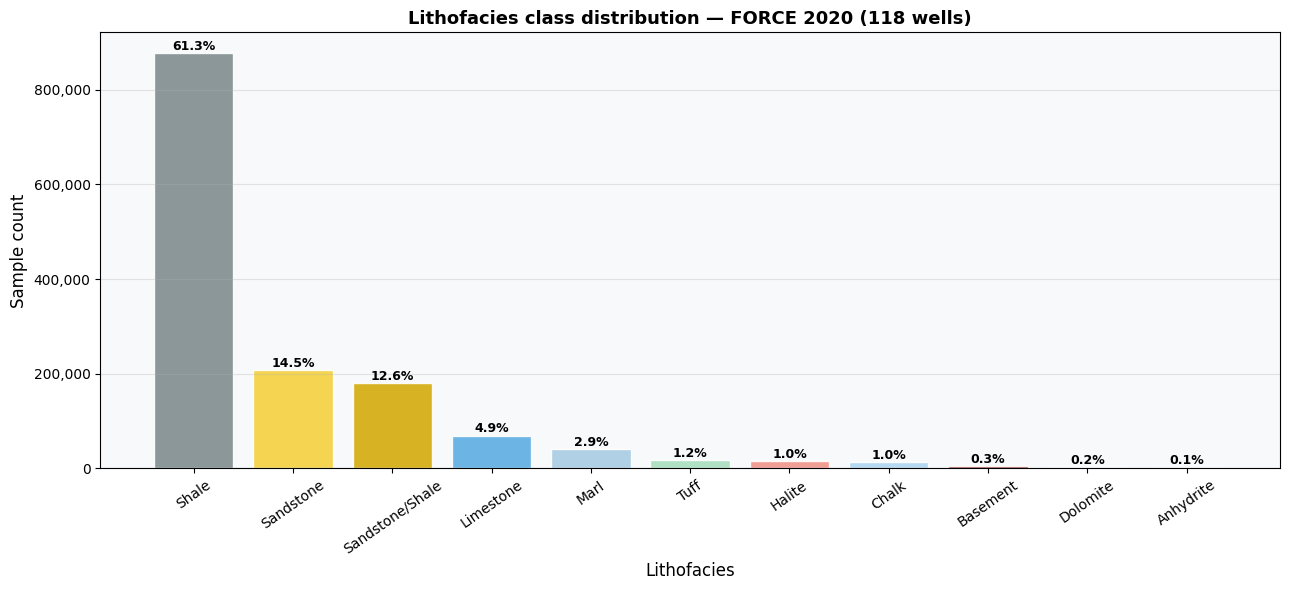

Saved fig02_lithofacies_distribution.png


In [7]:
fig, ax = plt.subplots(figsize=(13, 6))
colors = [LITH_COLORS.get(l, "#888") for l in lith_counts.index]
bars   = ax.bar(lith_counts.index, lith_counts.values, color=colors, alpha=0.9, edgecolor="white")
for bar, val in zip(bars, lith_counts.values):
    pct = val / len(labelled) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xlabel("Lithofacies", fontsize=12)
ax.set_ylabel("Sample count", fontsize=12)
ax.set_title("Lithofacies class distribution — FORCE 2020 (118 wells)", fontweight="bold", fontsize=13)
ax.tick_params(axis="x", rotation=35)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / "fig02_lithofacies_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig02_lithofacies_distribution.png")


## 4. Single well log viewer — classic petrophysicist track plot

Plotting well: 15_9-13  (18,270 samples)


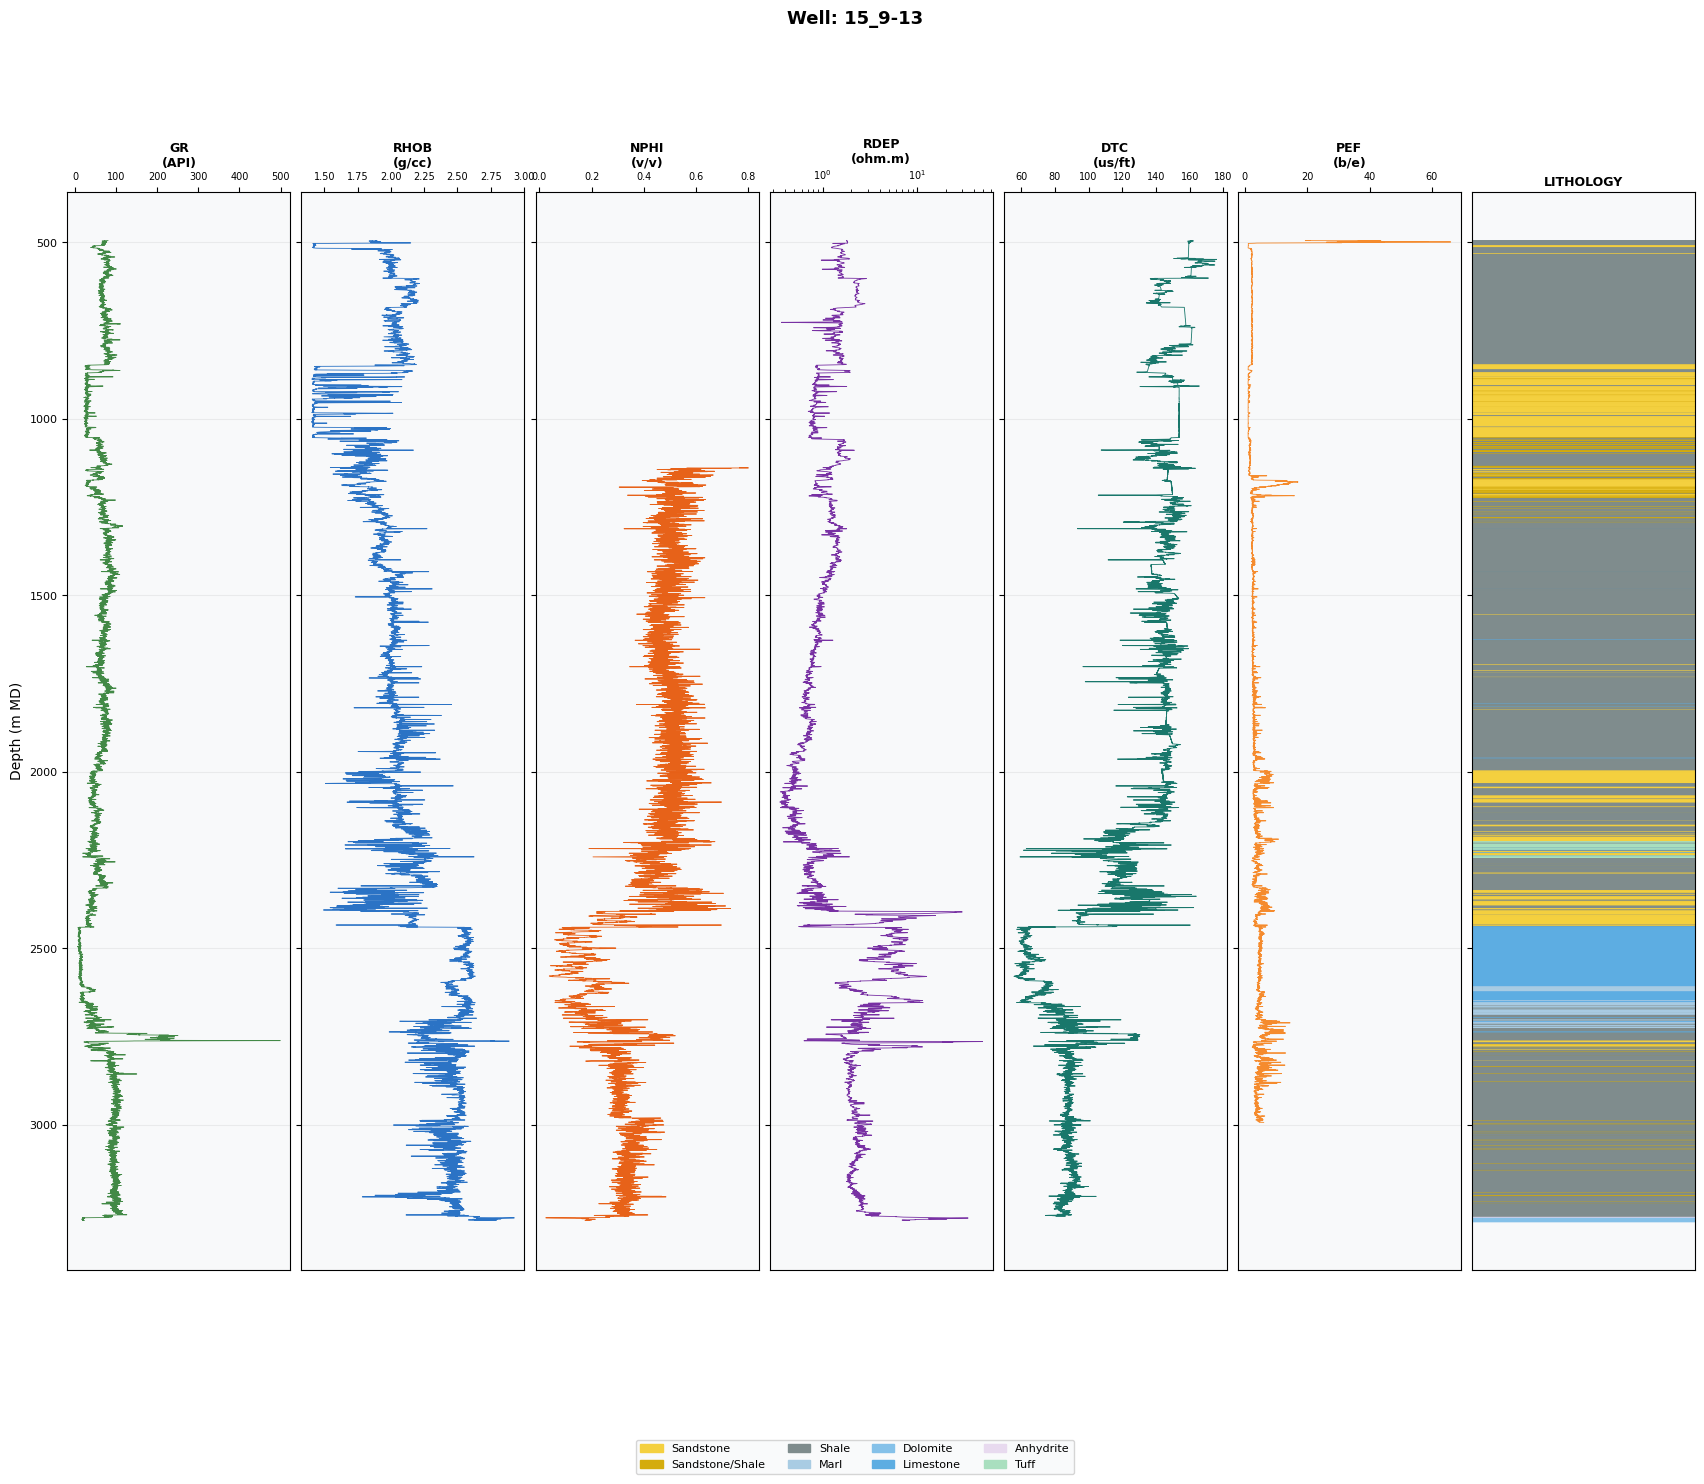

Saved fig03_well_log_viewer.png


In [8]:
def plot_well_log(df, well_name, curves=None, depth_col="DEPTH_MD", lith_col="LITHOFACIES"):
    if curves is None:
        curves = ["GR", "RHOB", "NPHI", "RDEP", "DTC"]
    available = [c for c in curves if c in df.columns and df[c].notna().sum() > 0]
    if not available:
        print(f"No curves for {well_name}"); return None

    track_cfg = {
        "GR"  : ("#2E7D32", False, "API"),
        "RHOB": ("#1565C0", False, "g/cc"),
        "NPHI": ("#E65100", False, "v/v"),
        "RDEP": ("#6A1B9A", True,  "ohm.m"),
        "RMED": ("#AD1457", True,  "ohm.m"),
        "DTC" : ("#00695C", False, "us/ft"),
        "PEF" : ("#F57F17", False, "b/e"),
        "SP"  : ("#3E2723", False, "mV"),
        "CALI": ("#37474F", False, "in"),
    }
    n_tracks = len(available) + 1
    fig, axes = plt.subplots(1, n_tracks, figsize=(3*n_tracks, 14),
                             sharey=True, gridspec_kw={"wspace": 0.05})
    if n_tracks == 1: axes = [axes]
    depth = df[depth_col]

    for ax, curve in zip(axes[:-1], available):
        color, log_scale, unit = track_cfg.get(curve, ("#555", False, ""))
        ax.plot(df[curve], depth, color=color, lw=0.6, alpha=0.9)
        if log_scale and df[curve].dropna().min() > 0:
            ax.set_xscale("log")
        ax.set_xlabel(f"{curve}\n({unit})", fontsize=9, fontweight="bold")
        ax.grid(True, alpha=0.2, axis="y")
        ax.invert_yaxis()
        ax.xaxis.set_label_position("top"); ax.xaxis.tick_top()
        ax.tick_params(axis="x", labelsize=7); ax.tick_params(axis="y", labelsize=8)

    ax_lith = axes[-1]
    if lith_col in df.columns:
        for i in range(len(df) - 1):
            lith = df[lith_col].iloc[i]
            if pd.notna(lith):
                d1, d2 = depth.iloc[i], depth.iloc[i+1]
                ax_lith.fill_betweenx([d1, d2], 0, 1,
                                      color=LITH_COLORS.get(lith, "#CCC"), alpha=0.9)
    ax_lith.set_xlim(0, 1); ax_lith.set_xticks([])
    ax_lith.set_xlabel("LITHOLOGY", fontsize=9, fontweight="bold")
    ax_lith.xaxis.set_label_position("top"); ax_lith.invert_yaxis()
    axes[0].set_ylabel("Depth (m MD)", fontsize=10)
    fig.suptitle(f"Well: {well_name}", fontsize=13, fontweight="bold", y=1.01)
    patches = [mpatches.Patch(color=LITH_COLORS[l], label=l)
               for l in LITH_COLORS if l in df[lith_col].dropna().values]
    fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=8,
               bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    return fig

well_name = las_files[0].stem
well_df   = labelled[labelled["WELL"] == well_name].copy()
print(f"Plotting well: {well_name}  ({len(well_df):,} samples)")
fig = plot_well_log(well_df, well_name, curves=["GR","RHOB","NPHI","RDEP","DTC","PEF"])
if fig:
    fig.savefig(FIGS / "fig03_well_log_viewer.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved fig03_well_log_viewer.png")


## 5. GR vs RHOB and RHOB vs NPHI crossplots

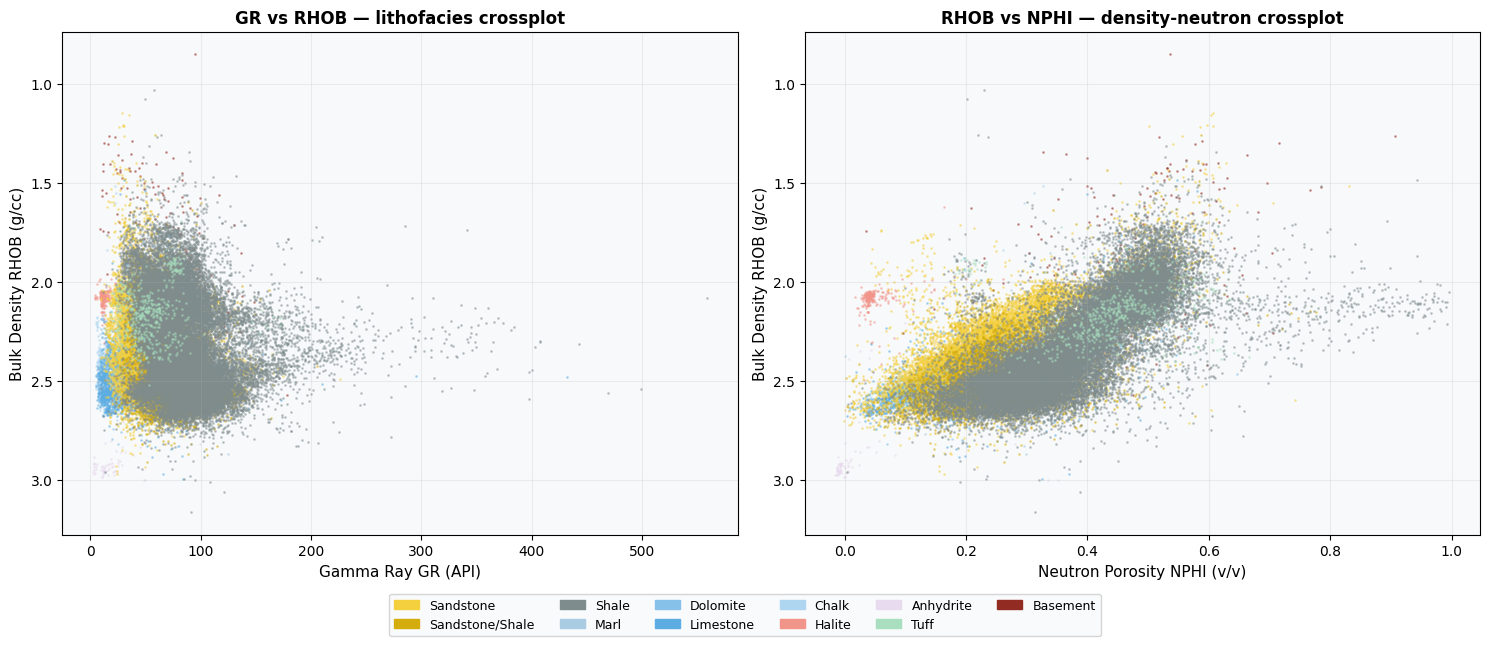

Saved fig04_crossplots.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sample = labelled.dropna(subset=["GR","RHOB","NPHI"]).sample(
    min(50000, len(labelled)), random_state=42)

ax = axes[0]
for lith, grp in sample.groupby("LITHOFACIES"):
    ax.scatter(grp["GR"], grp["RHOB"], c=LITH_COLORS.get(lith,"#888"),
               s=1, alpha=0.4, label=lith)
ax.set_xlabel("Gamma Ray GR (API)", fontsize=11)
ax.set_ylabel("Bulk Density RHOB (g/cc)", fontsize=11)
ax.set_title("GR vs RHOB — lithofacies crossplot", fontweight="bold")
ax.invert_yaxis(); ax.grid(alpha=0.2)

ax = axes[1]
for lith, grp in sample.groupby("LITHOFACIES"):
    ax.scatter(grp["NPHI"], grp["RHOB"], c=LITH_COLORS.get(lith,"#888"),
               s=1, alpha=0.4, label=lith)
ax.set_xlabel("Neutron Porosity NPHI (v/v)", fontsize=11)
ax.set_ylabel("Bulk Density RHOB (g/cc)", fontsize=11)
ax.set_title("RHOB vs NPHI — density-neutron crossplot", fontweight="bold")
ax.invert_yaxis(); ax.grid(alpha=0.2)

handles = [mpatches.Patch(color=LITH_COLORS[l], label=l)
           for l in LITH_COLORS if l in sample["LITHOFACIES"].values]
fig.legend(handles=handles, loc="lower center", ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig(FIGS / "fig04_crossplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig04_crossplots.png")


## 6. Null value analysis

Null value % per curve:
GR            1.7
RDEP          5.1
RMED         10.5
DTC          23.3
CALI         37.5
RHOB         40.3
DRHO         43.3
SP           47.4
ROP          47.8
NPHI         55.8
PEF          60.5
MUDWEIGHT    81.2


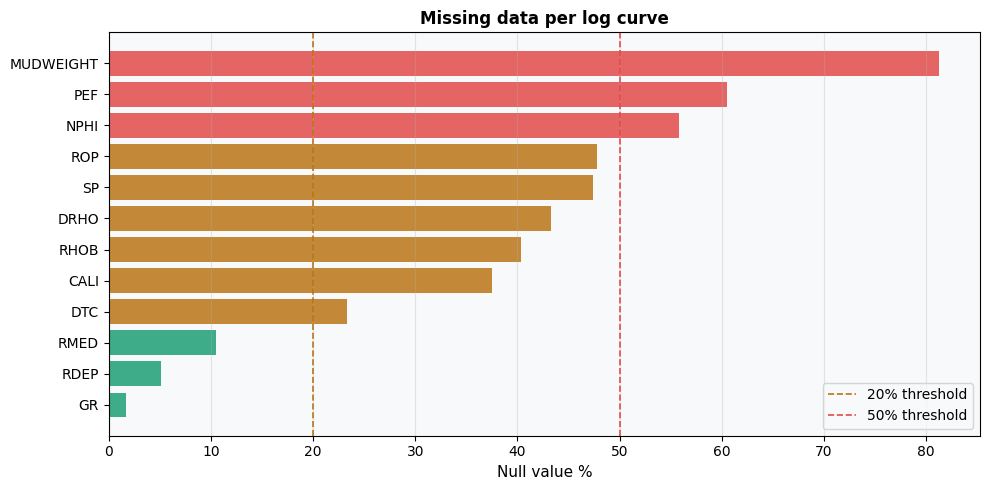

Saved fig05_null_analysis.png


In [10]:
null_pct = {}
for curve in STANDARD_CURVES:
    if curve in combined.columns:
        null_pct[curve] = round(combined[curve].isna().mean() * 100, 1)

null_df = pd.Series(null_pct).sort_values()
print("Null value % per curve:")
print(null_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#E24B4A" if v > 50 else "#BA7517" if v > 20 else "#1D9E75"
          for v in null_df.values]
ax.barh(null_df.index, null_df.values, color=colors, alpha=0.85)
ax.axvline(x=20, color="#BA7517", linestyle="--", lw=1.2, label="20% threshold")
ax.axvline(x=50, color="#E24B4A", linestyle="--", lw=1.2, label="50% threshold")
ax.set_xlabel("Null value %", fontsize=11)
ax.set_title("Missing data per log curve", fontweight="bold", fontsize=12)
ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / "fig05_null_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig05_null_analysis.png")


## 7. Per-lithofacies log distributions

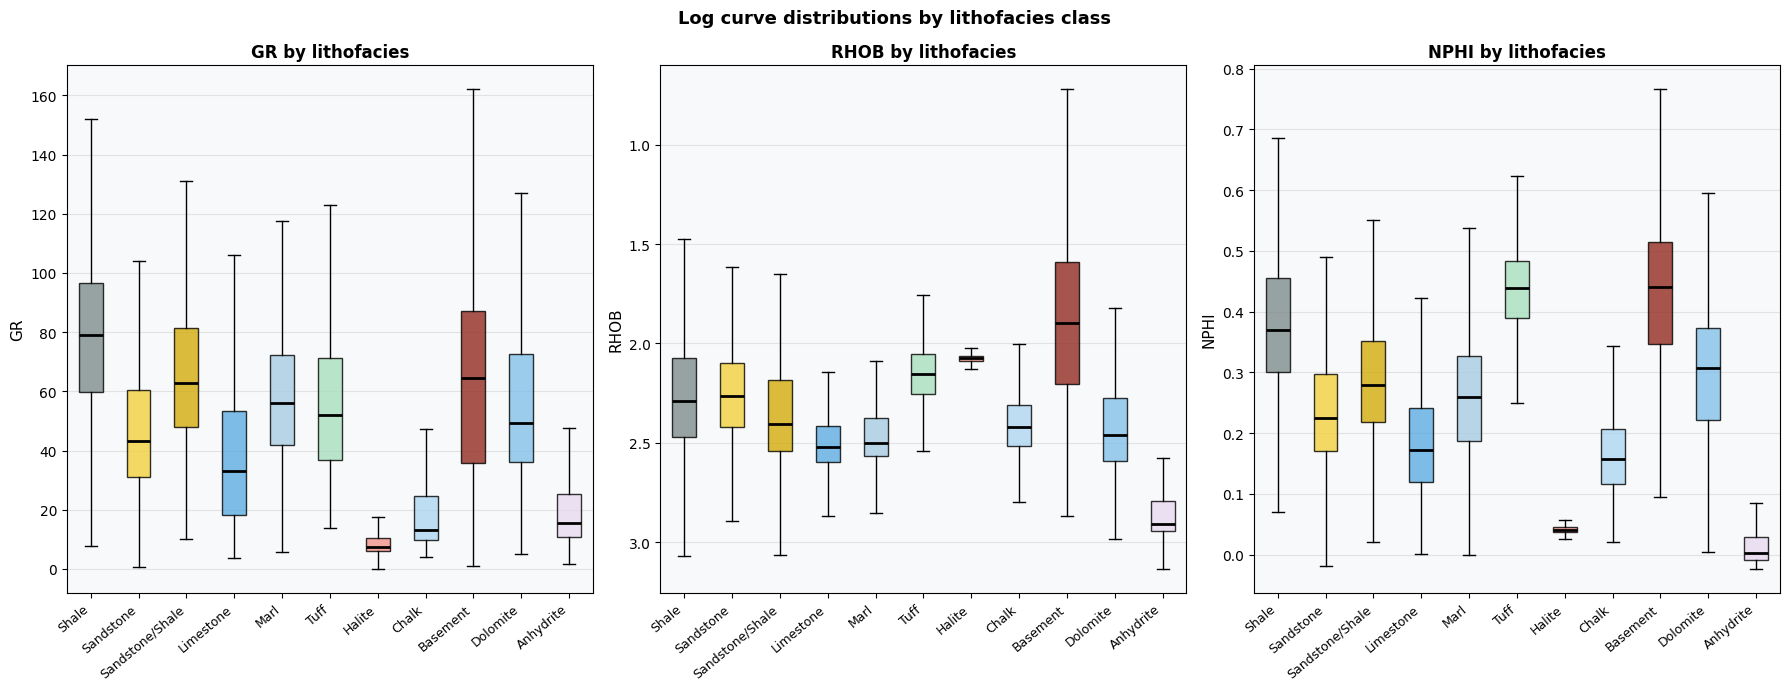

Saved fig07_per_lith_distributions.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, curve in zip(axes, ["GR", "RHOB", "NPHI"]):
    data_by_lith = [labelled[labelled["LITHOFACIES"] == l][curve].dropna().values
                    for l in lith_counts.index]
    bp = ax.boxplot(data_by_lith, patch_artist=True, showfliers=False,
                    medianprops={"color": "black", "lw": 2})
    for patch, lith in zip(bp["boxes"], lith_counts.index):
        patch.set_facecolor(LITH_COLORS.get(lith, "#888")); patch.set_alpha(0.8)
    ax.set_xticklabels(lith_counts.index, rotation=40, ha="right", fontsize=9)
    ax.set_ylabel(curve, fontsize=11)
    ax.set_title(f"{curve} by lithofacies", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    if curve == "RHOB": ax.invert_yaxis()

plt.suptitle("Log curve distributions by lithofacies class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "fig07_per_lith_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig07_per_lith_distributions.png")


## Summary

### Dataset statistics
- **118 wells**, Norwegian Sea, ~1.17M depth samples at 0.15m intervals
- **12 lithofacies classes** — highly imbalanced (Shale dominates)

### Curve availability
- **GR, RHOB, NPHI, RDEP, RMED** — available in nearly all wells → core features
- **DTC, PEF, SP** — 60–80% well coverage → secondary features
- **DTS** (shear sonic) — rare, exclude from baseline

### Class imbalance
- Shale is the dominant class (~50%+)
- Coal, Basement, Halite, Tuff are rare — will need SMOTE or class weighting
- Sandstone vs Sandstone/Shale most likely to be confused

### Key petrophysical observations
- GR cleanly separates clean sands (low) from shales (high) and coal (very low)
- Coal is most distinctive: very low RHOB (~1.3 g/cc), very high NPHI
- RHOB-NPHI crossplot shows distinct lithofacies clustering

### Missing data strategy for Notebook 02
- Replace LAS nulls (-999.25) with NaN — done
- Per-well median imputation for CORE_CURVES
- Indicator columns for missing secondary curves (DTC, PEF, SP)

